# Project Milestone One: Gathering your Team, Understanding the Problem,  Exploring the Data

#### Due: Midnight on March 29th (with 2-hour grace period)  

#### There will be no late period on this homework, as we need to start manual grading immediately!



### What We Will Do in This Milestone Assignment

1. You will convene your team and fill out the Team Contract (in the Homework Repo), to be submitted to Gradescope.
2. You must select a team leader for the purpose of submitting this notebook, after the team collaborates to complete the assignment. This <a href=https://guides.gradescope.com/hc/en-us/articles/21863861823373-Adding-Group-Members-to-a-Submission>link</a> describes how to add group members to your leader's submission.
3. At the conclusion of your work on this Milestone, you will complete an Individual Evaluation of your team's work (in the Homework Repo) and upload it *individually* to Gradescope.
4. We will follow a simplified version of the **Machine Learning Project Checklist** in Appendix A in our textbook *Hands-On Machine Learning* (pp.779):  

>Part 1:	Frame the problem and look at the big picture  
Part 2: Download and perform preliminary exploration of the data  
Part 3: Clean the Data: Drop, Impute, and Encode   
Part 4: Explore Feature Relationships  
Part 5: Investigate Feature Engineering options to better expose the underlying data patterns  

### The Dataset

All teams will use the same dataset. It is a smaller version of the Zillow housing dataset that was used in the
Zillow Million Dollar Prize which ran on Kaggle in 2017 (sorry, the contest is closed, so you can't win any money
with this project!).  We will try to predict the assessed tax value (`'taxvaluedollarcnt'`) of the property from a large collection
of descriptors. Some features are closely related and some are obviously useless.  There are potential outliers and also quite a few missing values.

This is a good example of a dataset which has not been predigested for you on Kaggle, and should give you a good chance to
try all the various tools in your toolbox!


In [44]:
# =============================
# Useful Imports
# =============================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



## Prelude: Download the Zillow Housing Dataset

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.**

For a detailed description of the dataset features, please refer to  **Appendix 1** below.

**Note:** Do **not** perform a train/test split for this milestone (unlike HOML suggests), since you need to do the split **after** any data preparation and feature engineering. You can wait until Milestone 2 to do the split.

In [45]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File already exists. Skipping download.


## Part 1: Frame the problem and look at the big picture [3 pts]

This part is a bit vague, since this project is not taking place in an actual business, but for the sake of exercizing all the steps, **pretend** that you are working at Zillow as a data analyst and are given this dataset and asked to
- Analyze and understand the data;
- Create a regression model;
- Give a presentation to the marketing team about your results.  

#### **1 Discussion:**

AFTER doing your EDA, come back and answer each of the following 3 questions in a *concise and informative paragraph between the lines;* you may wish to use your own business or home-buying experience, or to do some online research about the issues before you propose your ideas. (Don't stress about this, but *humor your professor and give it your best shot!*)


**1.1:**  What is the objective of this project in business terms?


The main goal of this project is to build a regression model that can predict the assessed tax value of a property using its features like size, location, number of rooms, year built, and other characteristics. For Zillow, this is very useful because it helps to give accurate property value estimates to buyers, sellers, and real estate agents. If the model works well, it can help the company give better price suggestions, which makes customers trust the platform more and improves the business.


**1.2:**  How will your solution be used?


The solution will be used to automatically estimate property tax values based on property characteristics. When a user looks at a house on Zillow, the model can show an estimated value right away. The marketing team can also use the results to understand which features matter most for property value (for example, our data shows that square footage and bathroom count have the strongest correlation with price). This information can help create better marketing content and help customers make better decisions.

**1.3:**  How should success (or failure) be measured?


We should measure success using regression metrics like RMSE (Root Mean Squared Error) and R-squared. A low RMSE means the model predictions are close to the real tax values, and a high R-squared means the model explains most of the variation in the data. We can also compare our model against a baseline (for example, always predicting the median value of about $358,879). If the model beats the baseline by a large amount, we can say it is successful. We will use cross-validation to make sure the model works well on unseen data too.

## Part 2: Download and perform preliminary exploration of the data [4 pts]

### Part 2.A: Load the data into a dataframe and study each feature/column and its characteristics:
- Name
- Type (categorical, int/float, text, etc.)
- Apparent usefulness for the task
- Approximate % of missing values
- How many unique values

**Note:** The **target** is the last column `'taxvaluedollarcnt'` -- pay particular attention to this during the EDA process.
  
Hint: Just use `.head()`, `.info()`, and `.nunique()`.

In [46]:
# Look at the first few rows
df.head()

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,...,NaN,NaN,1998.0,NaN,NaN,2016.0,NaN,NaN,6.059063e+13,1023282.0
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,...,NaN,NaN,1967.0,1.0,NaN,2016.0,NaN,NaN,6.111001e+13,464000.0
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,...,NaN,NaN,1962.0,1.0,NaN,2016.0,NaN,NaN,6.059022e+13,564778.0
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1970.0,NaN,NaN,2016.0,NaN,NaN,6.037300e+13,145143.0
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1964.0,NaN,NaN,2016.0,NaN,NaN,6.037124e+13,119407.0


In [47]:
# Check the shape of the dataset
print(f"Dataset shape: {df.shape}")
print(f"Number of samples: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")

Dataset shape: (77613, 55)
Number of samples: 77613
Number of features: 55


In [48]:
# Detailed info about each feature
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12  finishedsquarefeet12          73923 non-null  float64
 13  f

In [49]:
# Number of unique values per feature
print("Unique values per feature:")
print(df.nunique())

Unique values per feature:
parcelid                        77414
airconditioningtypeid               5
architecturalstyletypeid            5
basementsqft                       43
bathroomcnt                        22
bedroomcnt                         16
buildingclasstypeid                 2
buildingqualitytypeid              12
calculatedbathnbr                  21
decktypeid                          1
finishedfloor1squarefeet         1787
calculatedfinishedsquarefeet     4972
finishedsquarefeet12             4868
finishedsquarefeet13               13
finishedsquarefeet15             1724
finishedsquarefeet50             1807
finishedsquarefeet6               350
fips                                3
fireplacecnt                        5
fullbathcnt                        13
garagecarcnt                       14
garagetotalsqft                   839
hashottuborspa                      1
heatingorsystemtypeid              10
latitude                        64038
longitude              

In [50]:
# Show null counts and percentages for all features
def show_null_counts(df):
    count_nulls = df.isnull().sum()
    pct_nulls = (df.isnull().mean() * 100).round(2)
    n_unique = df.nunique()
    dtypes = df.dtypes

    null_info = pd.DataFrame({
        'Dtype': dtypes,
        'Null Count': count_nulls,
        'Null %': pct_nulls,
        'Unique': n_unique
    })

    # Sort by null percentage descending
    null_info = null_info.sort_values('Null %', ascending=False)
    return null_info

null_info = show_null_counts(df)
print("\nFeatures sorted by % of missing values:")
display(null_info)


Features sorted by % of missing values:


,Dtype,Null Count,Null %,Unique
buildingclasstypeid,float64,77598,99.98,2
finishedsquarefeet13,float64,77571,99.95,13
basementsqft,float64,77563,99.94,43
storytypeid,float64,77563,99.94,1
yardbuildingsqft26,float64,77543,99.91,59
fireplaceflag,object,77441,99.78,1
architecturalstyletypeid,float64,77406,99.73,5
typeconstructiontypeid,float64,77390,99.71,4
finishedsquarefeet6,float64,77227,99.50,350
pooltypeid10,float64,77148,99.40,1


#### **2.A Discussion:** Answer the following questions.

**2.A.1:**  Which features are categorical?

Looking at the data with `df.info()`, the features with `object` dtype are categorical: `propertycountylandusecode`, `propertyzoningdesc`, `hashottuborspa`, `fireplaceflag`, and `taxdelinquencyflag`. Also, some numeric features are actually categorical IDs: `fips` (county code with 3 unique values), `regionidcity`, `regionidcounty`, `regionidzip`, and `regionidneighborhood` are all region identifiers, not true numbers. Features like `airconditioningtypeid` (5 unique values) and `heatingorsystemtypeid` are also categorical IDs stored as numbers.

**2.A.2:**  Are there any features which appear at first glance to be **useless** for the business purpose of this project and should be deleted?  Give examples and describe your reasoning briefly.

Yes. `parcelid` has 77,414 unique values out of 77,613 rows, so it is just a unique ID with no predictive value. `rawcensustractandblock` and `censustractandblock` are long census ID numbers that are not useful for prediction. `assessmentyear` has only 1 unique value (all properties were assessed in the same year), so it provides no information. `propertycountylandusecode` and `propertyzoningdesc` are text codes with many unique values that are hard to use in a model.

**2.A.3:**  Are there any features which appear to be **useless** because of the percentage of missing values?  If so, give an example.

Yes, many features have very high percentages of missing values. For example: `buildingclasstypeid` has 99.98% null, `finishedsquarefeet13` has 99.95% null, `basementsqft` and `storytypeid` have 99.94% null, and `yardbuildingsqft26` has 99.91% null. With so little data available, imputation would not be reliable. In total, we found 29 features with more than 50% missing values, and these should be dropped.

**2.A.4:**  Are there any features which appear to be **useless** because of the number of unique values?  If so, give an example.

Yes. `assessmentyear` has only 1 unique value, so it gives zero information to the model. `decktypeid` also has only 1 unique value in its non-null rows (and 99.21% are null). On the other side, `parcelid` has 77,414 unique values (almost one per row), which means it is just an ID and not a useful predictor. `rawcensustractandblock` is similar with too many unique values to be useful.

### Part 2.B: Exploratory Data Analysis (EDA) -- Feature-Level Visualization  

- To get an overview, generate histograms for all features using `df.hist()`  (Hint: increase the figsize and set the layout to `(-1,m)` to get  `m` columns and as many rows as necessary.)
- Generate individual visualizations for the **target and three (3)** other interesting-looking features in the dataset (i.e., a total of 4):  
    - Use appropriate plot types (e.g., histograms and boxplots for numerical features, bar plots for categorical features) to understand distributions and identify potential outliers for these three.
    - Use as many code cells as you need, and give comments describing what each cell does.
    - Answer the discussion question posed (you should choose 3 features for which you can say something interesting in the discussion).  

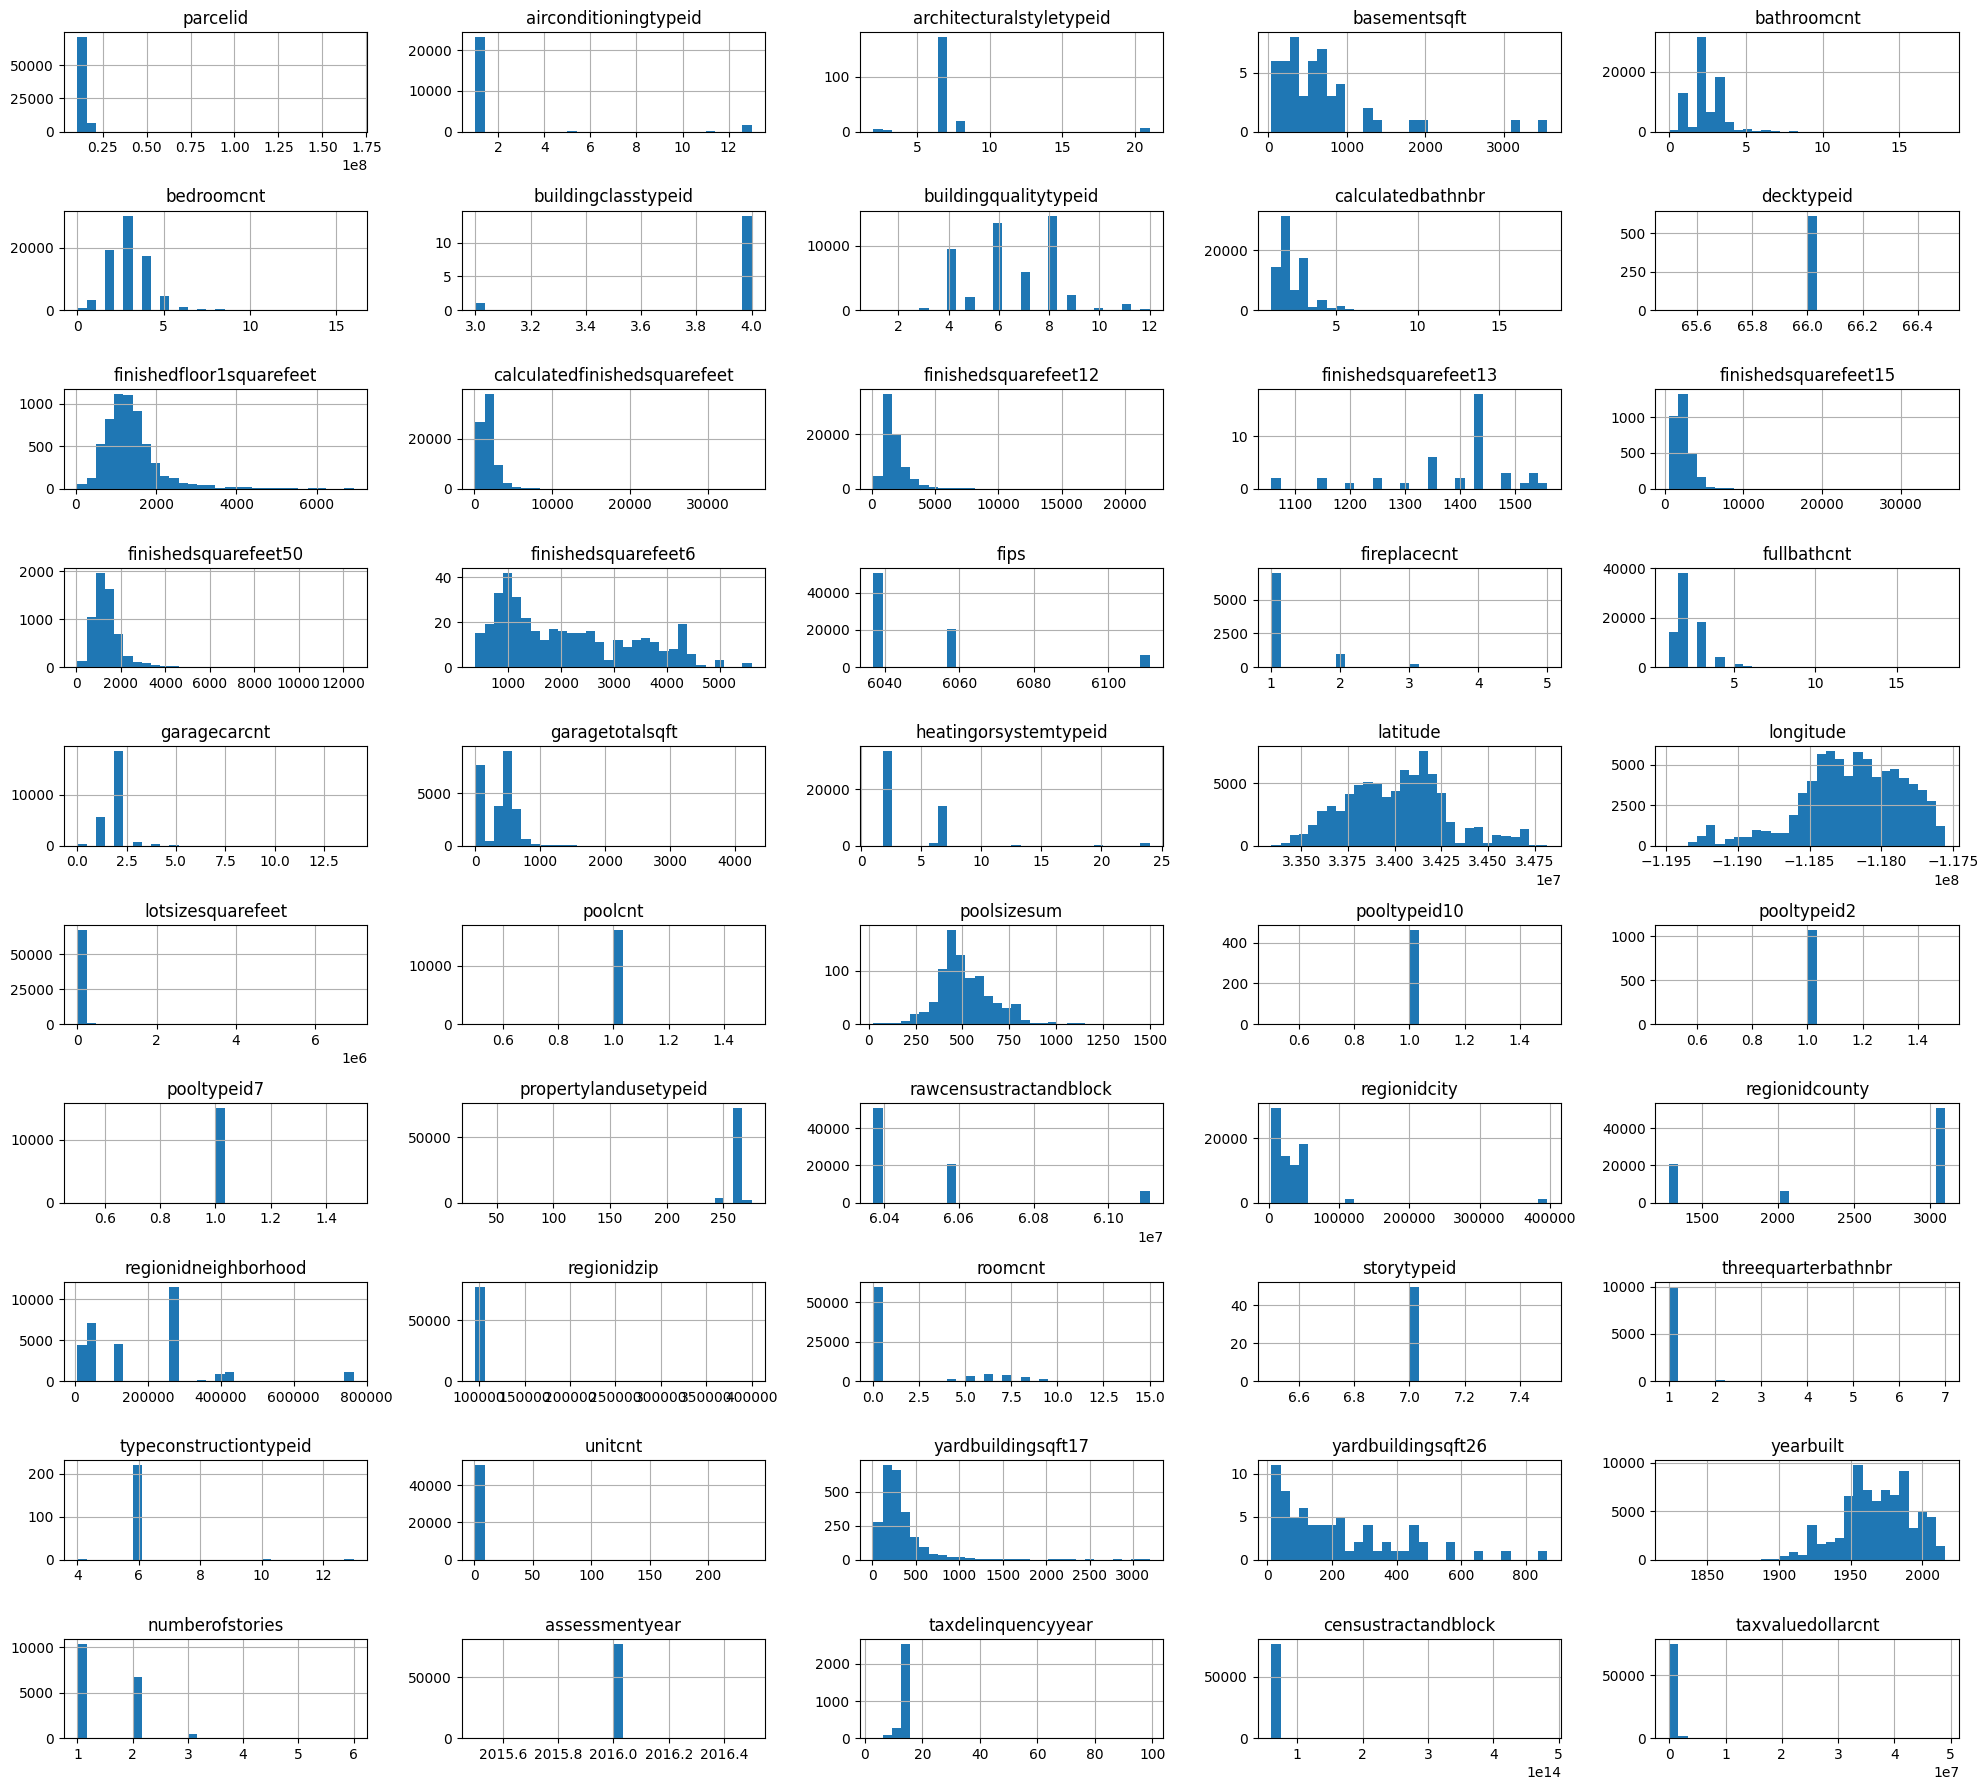

In [51]:
# Histograms for all numeric features
df.hist(figsize=(20, 18), bins=30, layout=(-1, 5))
plt.tight_layout()
plt.show()

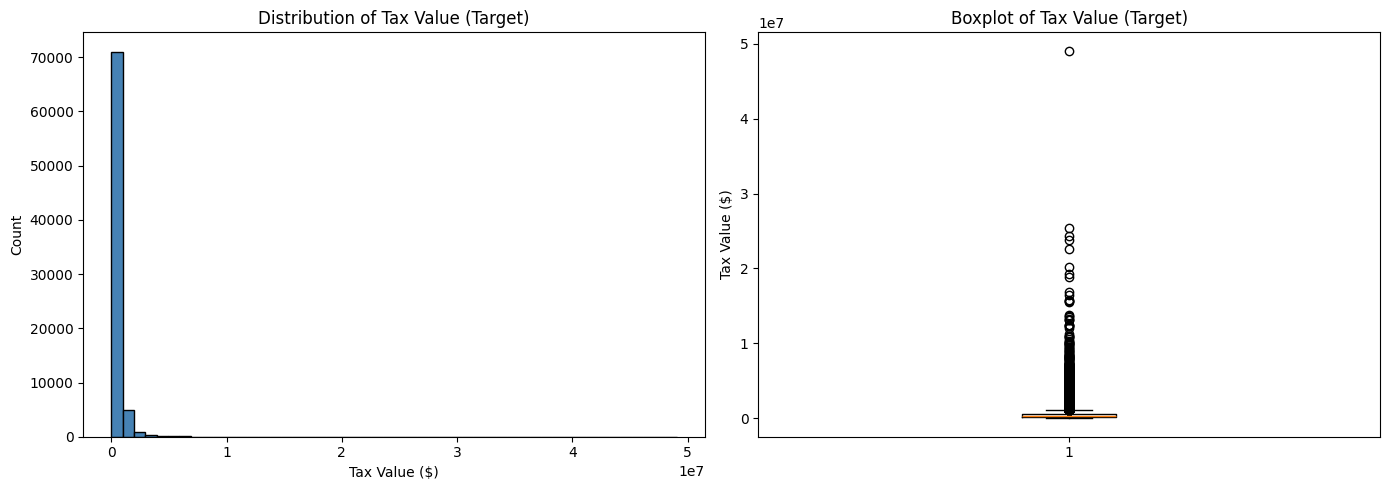

Target stats:
count    7.757800e+04
mean     4.901506e+05
std      6.537979e+05
min      1.000000e+03
25%      2.068985e+05
50%      3.588785e+05
75%      5.690000e+05
max      4.906124e+07
Name: taxvaluedollarcnt, dtype: float64


In [52]:
# Feature 1: TARGET - taxvaluedollarcnt (assessed tax value)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['taxvaluedollarcnt'].dropna(), bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Tax Value (Target)')
axes[0].set_xlabel('Tax Value ($)')
axes[0].set_ylabel('Count')

# Boxplot
axes[1].boxplot(df['taxvaluedollarcnt'].dropna(), vert=True)
axes[1].set_title('Boxplot of Tax Value (Target)')
axes[1].set_ylabel('Tax Value ($)')

plt.tight_layout()
plt.show()

print(f"Target stats:")
print(df['taxvaluedollarcnt'].describe())

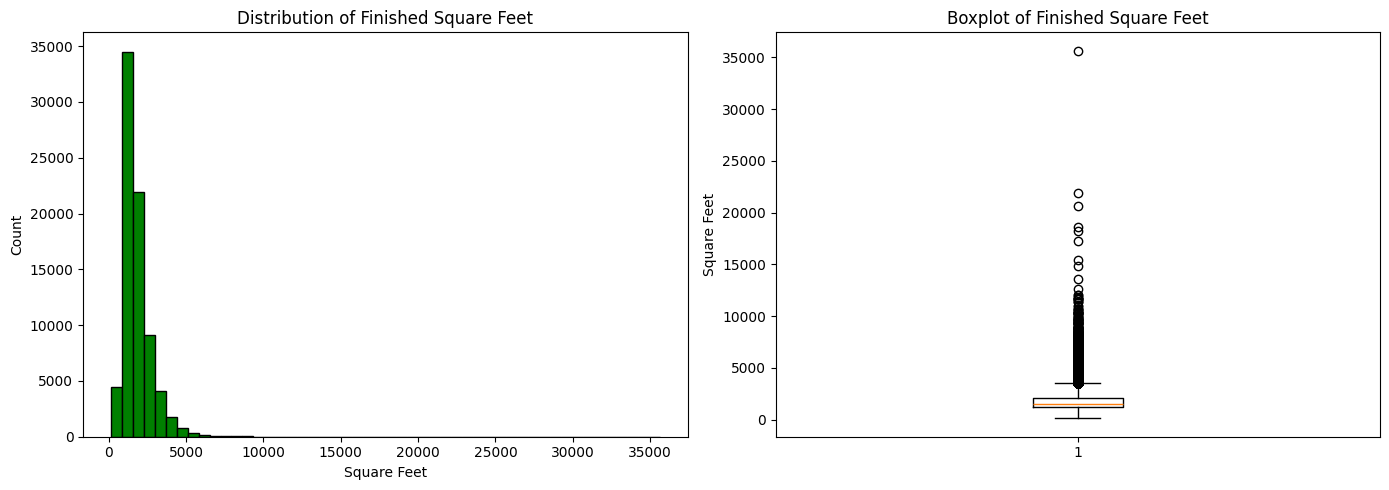

count    77378.000000
mean      1784.935421
std        954.250373
min        128.000000
25%       1182.000000
50%       1542.000000
75%       2112.000000
max      35640.000000
Name: calculatedfinishedsquarefeet, dtype: float64


In [53]:
# Feature 2: calculatedfinishedsquarefeet (total finished living area)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['calculatedfinishedsquarefeet'].dropna(), bins=50, color='green', edgecolor='black')
axes[0].set_title('Distribution of Finished Square Feet')
axes[0].set_xlabel('Square Feet')
axes[0].set_ylabel('Count')

axes[1].boxplot(df['calculatedfinishedsquarefeet'].dropna(), vert=True)
axes[1].set_title('Boxplot of Finished Square Feet')
axes[1].set_ylabel('Square Feet')

plt.tight_layout()
plt.show()

print(df['calculatedfinishedsquarefeet'].describe())

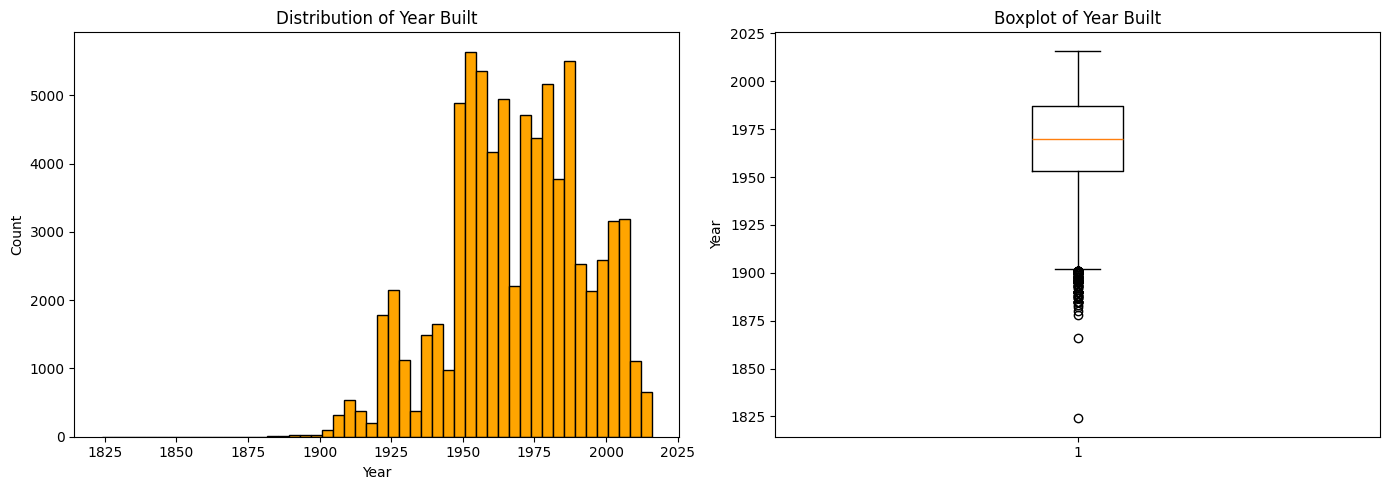

count    77309.000000
mean      1968.611507
std         23.793171
min       1824.000000
25%       1953.000000
50%       1970.000000
75%       1987.000000
max       2016.000000
Name: yearbuilt, dtype: float64


In [54]:
# Feature 3: yearbuilt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['yearbuilt'].dropna(), bins=50, color='orange', edgecolor='black')
axes[0].set_title('Distribution of Year Built')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')

axes[1].boxplot(df['yearbuilt'].dropna(), vert=True)
axes[1].set_title('Boxplot of Year Built')
axes[1].set_ylabel('Year')

plt.tight_layout()
plt.show()

print(df['yearbuilt'].describe())

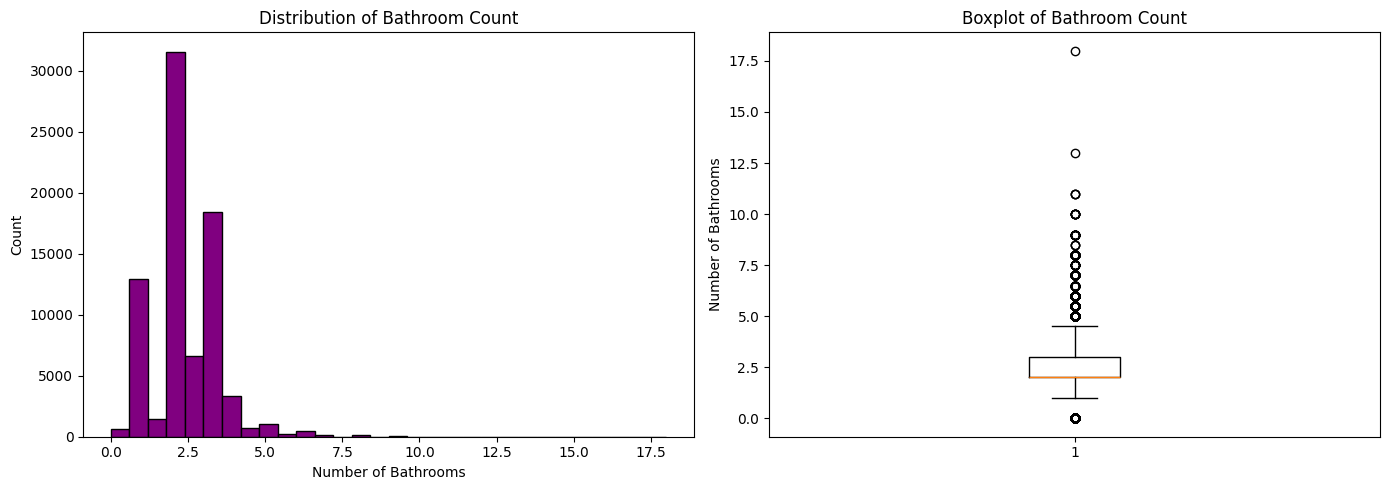

count    77579.000000
mean         2.298496
std          0.996732
min          0.000000
25%          2.000000
50%          2.000000
75%          3.000000
max         18.000000
Name: bathroomcnt, dtype: float64


In [55]:
# Feature 4: bathroomcnt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['bathroomcnt'].dropna(), bins=30, color='purple', edgecolor='black')
axes[0].set_title('Distribution of Bathroom Count')
axes[0].set_xlabel('Number of Bathrooms')
axes[0].set_ylabel('Count')

axes[1].boxplot(df['bathroomcnt'].dropna(), vert=True)
axes[1].set_title('Boxplot of Bathroom Count')
axes[1].set_ylabel('Number of Bathrooms')

plt.tight_layout()
plt.show()

print(df['bathroomcnt'].describe())

#### **2.B Discussion:** Describe in a paragraph what you learned in your detailed examination of the features you explored:
- What is the distribution (normal, exponential, etc.) if any?
- Any problems (e.g., outliers, any odd characteristics)?
- Anything else interesting? Why did you choose it?


**Target (taxvaluedollarcnt):** The distribution is strongly right-skewed, with a mean of $490,151 but a median of $358,879. The max value is $49,061,240, which is a very extreme outlier. The boxplot shows many outliers above $1 million. We will need to remove extreme outliers before modeling.

**Finished Square Feet (calculatedfinishedsquarefeet):** Also right-skewed, with a mean of 1,785 sqft and a median of 1,542 sqft. The max is 35,640 sqft, which is an extreme outlier. We chose this feature because square footage is typically one of the strongest predictors of property value, and our correlation analysis confirms this (correlation = 0.575 with the target).

**Year Built (yearbuilt):** Most properties were built between 1950 and 2010, with a median of 1970 and a minimum of 1824. The distribution is slightly left-skewed, with more newer properties. We chose this feature because age of the property can affect its value.

**Bathroom Count (bathroomcnt):** Most properties have 1 to 3 bathrooms (median = 2). The max is 18, which could be a data entry error or a very large property. We chose this because it has a strong correlation with the target (0.471).

## Part 3:  Clean the Data: Drop, Impute, and Encode [6 pts]



**Important Notes:**
- You should review your Homework 4 before doing this section!
- Create new names for modified data at each stage to avoid problems with global variables.
- Whenever possible, write functions for all data transformations you apply, for these reasons:
    - So you can easily prepare the data the next time you get a fresh dataset
    - So you can apply these transformations in future projects
    - To clean and prepare new data instances once your solution is live
    - To make it easy to treat your preparation choices as hyperparameters
    - [To apply the same transformations to your test set if train/test split already done -- not applicable here]

### Part 3.A: Drop features you judge to be unsuitable for the regression task

Your call, based on any research you can do to understand the feature (hopefully IRL you would have a domain expert to help with this, but do your best).   

Note: Do not drop features because of too many missing values, that's the next task!

In [56]:

# List of features to drop and reasons:
# parcelid - unique ID, not a predictor
# rawcensustractandblock - long ID number, not useful
# censustractandblock - same as above, ID number
# assessmentyear - likely same value for all rows
# propertycountylandusecode - text code, too many unique values
# propertyzoningdesc - text description, too many unique values
# propertylandusetypeid - land use type, redundant with other features

cols_to_drop_unsuitable = [
    'parcelid',
    'rawcensustractandblock',
    'censustractandblock',
    'assessmentyear',
    'propertycountylandusecode',
    'propertyzoningdesc',
    'propertylandusetypeid'
]

# Only drop columns that exist in the dataframe
cols_to_drop_unsuitable = [c for c in cols_to_drop_unsuitable if c in df.columns]

df_clean = df.drop(columns=cols_to_drop_unsuitable)

print(f"Dropped {len(cols_to_drop_unsuitable)} unsuitable features: {cols_to_drop_unsuitable}")
print(f"Remaining features: {df_clean.shape[1]}")

Dropped 7 unsuitable features: ['parcelid', 'rawcensustractandblock', 'censustractandblock', 'assessmentyear', 'propertycountylandusecode', 'propertyzoningdesc', 'propertylandusetypeid']
Remaining features: 48


#### **3.A Discussion:** Justify in a paragraph your decisions about which features to drop.


We dropped 7 features that are not useful for predicting tax values. `parcelid` is just a unique ID (77,414 unique values) with no predictive power. `rawcensustractandblock` and `censustractandblock` are long census identifiers that do not add useful information. `assessmentyear` has only 1 unique value, so it cannot help the model distinguish between properties. `propertycountylandusecode` and `propertyzoningdesc` are text codes with too many unique categories to encode well. `propertylandusetypeid` is redundant since most properties share the same value. After this step, we went from 55 features to 48.

### Part 3.B: Drop **features** with "too many" null values

Your code in the next cell(s). Make a judgement call about what "too many" means and briefly describe your reasoning in the discussion.   

Note: "Too many" may depend on what the non-null values look like, be sure to investigate carefully.

In [57]:
# Check null percentages in the cleaned dataset
null_pct = (df_clean.isnull().mean() * 100).round(2)
print("Features with more than 50% null values:")
print(null_pct[null_pct > 50].sort_values(ascending=False))

Features with more than 50% null values:
buildingclasstypeid         99.98
finishedsquarefeet13        99.95
basementsqft                99.94
storytypeid                 99.94
yardbuildingsqft26          99.91
fireplaceflag               99.78
architecturalstyletypeid    99.73
typeconstructiontypeid      99.71
finishedsquarefeet6         99.50
pooltypeid10                99.40
decktypeid                  99.21
poolsizesum                 98.88
pooltypeid2                 98.62
hashottuborspa              98.02
yardbuildingsqft17          96.92
taxdelinquencyflag          96.26
taxdelinquencyyear          96.26
finishedsquarefeet15        96.10
finishedsquarefeet50        92.22
finishedfloor1squarefeet    92.22
fireplacecnt                89.32
threequarterbathnbr         86.98
pooltypeid7                 80.57
poolcnt                     79.16
numberofstories             77.32
airconditioningtypeid       67.78
garagecarcnt                67.12
garagetotalsqft             67.12
regioni

In [58]:
# Drop features with more than 50% missing values
null_threshold = 50  # percent

null_pct = (df_clean.isnull().mean() * 100)
cols_too_many_nulls = null_pct[null_pct > null_threshold].index.tolist()

df_clean2 = df_clean.drop(columns=cols_too_many_nulls)

print(f"Dropped {len(cols_too_many_nulls)} features with more than {null_threshold}% null values:")
print(cols_too_many_nulls)
print(f"\nRemaining features: {df_clean2.shape[1]}")

Dropped 29 features with more than 50% null values:
['airconditioningtypeid', 'architecturalstyletypeid', 'basementsqft', 'buildingclasstypeid', 'decktypeid', 'finishedfloor1squarefeet', 'finishedsquarefeet13', 'finishedsquarefeet15', 'finishedsquarefeet50', 'finishedsquarefeet6', 'fireplacecnt', 'garagecarcnt', 'garagetotalsqft', 'hashottuborspa', 'poolcnt', 'poolsizesum', 'pooltypeid10', 'pooltypeid2', 'pooltypeid7', 'regionidneighborhood', 'storytypeid', 'threequarterbathnbr', 'typeconstructiontypeid', 'yardbuildingsqft17', 'yardbuildingsqft26', 'numberofstories', 'fireplaceflag', 'taxdelinquencyflag', 'taxdelinquencyyear']

Remaining features: 19


#### **3.B Discussion:** In a paragraph, explain your decision about which features were dropped



We used a threshold of 50% missing values. If more than half of a feature's values are missing, imputation becomes unreliable because we would be creating more data than we actually have. Using this threshold, we dropped 29 features. Some had extremely high null rates like `buildingclasstypeid` (99.98%), `basementsqft` (99.94%), and `storytypeid` (99.94%). Others like `airconditioningtypeid` (67.78%), `fireplacecnt` (59.71%), and `garagecarcnt` (62.52%) were also above the threshold. After this step, we went from 48 features to 19 features. While 50% is a common threshold, the remaining 19 features still include the most important predictors like square footage, bathroom count, and year built.

### Part 3.C: Drop Problematic **samples**

There could be several reasons why you might want to drop a sample:
- It has  "too many" null values
- It has a null value in the target
- It contains outliers, especially in the target



Your code in the next cell(s). Make a judgement call about which samples should be dropped and briefly describe your reasoning in the discussion.   


In [59]:
# Step 1: Drop rows where the target is null
before = df_clean2.shape[0]
df_clean3 = df_clean2.dropna(subset=['taxvaluedollarcnt'])
after = df_clean3.shape[0]
print(f"Dropped {before - after} rows with null target values")

Dropped 35 rows with null target values


In [60]:
# Step 2: Remove outliers in the target using IQR method
Q1 = df_clean3['taxvaluedollarcnt'].quantile(0.01)
Q99 = df_clean3['taxvaluedollarcnt'].quantile(0.99)

print(f"1st percentile: ${Q1:,.0f}")
print(f"99th percentile: ${Q99:,.0f}")

before = df_clean3.shape[0]
df_clean3 = df_clean3[(df_clean3['taxvaluedollarcnt'] >= Q1) &
                      (df_clean3['taxvaluedollarcnt'] <= Q99)]
after = df_clean3.shape[0]
print(f"Dropped {before - after} outlier rows based on target (1st-99th percentile)")

1st percentile: $39,708
99th percentile: $2,758,771
Dropped 1552 outlier rows based on target (1st-99th percentile)


In [61]:
# Step 3: Drop rows with too many null values (more than 50% of features)
null_per_row = df_clean3.isnull().mean(axis=1)

before = df_clean3.shape[0]
df_clean3 = df_clean3[null_per_row <= 0.5]
after = df_clean3.shape[0]
print(f"Dropped {before - after} rows with more than 50% null values")

print(f"\nFinal shape after dropping samples: {df_clean3.shape}")

Dropped 5 rows with more than 50% null values

Final shape after dropping samples: (76021, 19)


#### **3.C Discussion:** In a short paragraph, explain your decision about which samples were dropped


We dropped samples in three steps. First, we removed 35 rows where the target (`taxvaluedollarcnt`) was null, because we cannot train or evaluate without the true value. Second, we removed 1,552 outlier rows by keeping only values between the 1st percentile ($39,708) and the 99th percentile ($2,758,771). This removes extremely cheap or extremely expensive properties that could confuse the model. Third, we dropped 5 rows where more than 50% of the features were null, because these samples have too little information. In total, we went from 77,613 to 76,021 samples, losing only about 2% of the data.

### Part 3.D: Impute for the remaining missing values

Review the methods for imputation in **Appendix 2** and choose how you will impute the remainder of the missing values. Note:
- Consider whether different methods are justified for different features.
- In the next cells, apply your imputation methods to the dataset so that no null values remain after this step.
- Answer the discussion question.

In [62]:
# Make a copy for imputation
df_imputed = df_clean3.copy()

# Separate numeric and categorical features
numeric_features = df_imputed.select_dtypes(include=['number']).columns.tolist()
categorical_features = df_imputed.select_dtypes(exclude=['number']).columns.tolist()

print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"\nCategorical features ({len(categorical_features)}): {categorical_features}")

Numeric features (19): ['bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'fips', 'fullbathcnt', 'heatingorsystemtypeid', 'latitude', 'longitude', 'lotsizesquarefeet', 'regionidcity', 'regionidcounty', 'regionidzip', 'roomcnt', 'unitcnt', 'yearbuilt', 'taxvaluedollarcnt']

Categorical features (0): []


In [63]:
# Check remaining nulls before imputation
remaining_nulls = df_imputed.isnull().sum()
print("Features still with null values:")
print(remaining_nulls[remaining_nulls > 0].sort_values(ascending=False))

Features still with null values:
heatingorsystemtypeid           27554
buildingqualitytypeid           27362
unitcnt                         26569
lotsizesquarefeet                8205
finishedsquarefeet12             3517
regionidcity                     1440
calculatedbathnbr                 555
fullbathcnt                       555
yearbuilt                         221
calculatedfinishedsquarefeet      159
regionidzip                        45
dtype: int64


In [64]:
# Impute numeric features with median (robust to outliers)
num_imputer = SimpleImputer(strategy='median')

# Remove target from numeric features list for imputation
numeric_to_impute = [f for f in numeric_features if f != 'taxvaluedollarcnt']

df_imputed[numeric_to_impute] = num_imputer.fit_transform(df_imputed[numeric_to_impute])

print("Numeric features imputed with median.")

Numeric features imputed with median.


In [65]:
# Impute categorical features with most frequent value
if len(categorical_features) > 0:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    df_imputed[categorical_features] = cat_imputer.fit_transform(df_imputed[categorical_features])
    print("Categorical features imputed with most frequent value.")
else:
    print("No categorical features to impute.")

No categorical features to impute.


In [66]:
# Verify no null values remain
total_nulls = df_imputed.isnull().sum().sum()
print(f"Total remaining null values: {total_nulls}")
print(f"Dataset shape after imputation: {df_imputed.shape}")

Total remaining null values: 0
Dataset shape after imputation: (76021, 19)


#### **3.D Discussion:**  Describe in a paragraph your decisions about which methods you used to impute missing values in the dataset


After dropping high-null features, the remaining features still had some missing values. For example, `heatingorsystemtypeid` had 27,554 nulls (36%), `buildingqualitytypeid` had 27,362 nulls (36%), and `unitcnt` had 26,569 nulls (35%). Since all remaining features are numeric (no categorical features survived the cleaning process), we used median imputation for everything. Median is better than mean for this data because many features are right-skewed (like `lotsizesquarefeet` and `calculatedfinishedsquarefeet`), and the median is not affected by extreme values. After imputation, the dataset has zero null values and 76,021 samples with 19 features.

### 3.E: Encode the Categorical Features (if any)

You may not have any categorical features. If you do, encode them in the next step. No discussion is necessary.

In [67]:
df_encoded = df_imputed.copy()

categorical_features = df_encoded.select_dtypes(exclude=['number']).columns.tolist()

if len(categorical_features) > 0:
    encoder = OrdinalEncoder()
    df_encoded[categorical_features] = encoder.fit_transform(df_encoded[categorical_features])
    print(f"Encoded {len(categorical_features)} categorical features: {categorical_features}")
else:
    print("No categorical features to encode.")

# Verify all features are numeric now
print(f"\nAll dtypes are numeric: {df_encoded.select_dtypes(exclude=['number']).shape[1] == 0}")
print(f"Final dataset shape: {df_encoded.shape}")

No categorical features to encode.

All dtypes are numeric: True
Final dataset shape: (76021, 19)


## Part 4:  Investigate Feature Relationships  [6 pts]

In this part, we will investigate the feature relationships as a way of understanding the data.  In the next part, we'll investigate potential feature engineering opportunities.

**Note:**  We won't be committing to any changes to the data until Milestone 2, as our choice of transformations will very much depend on the model we're building. But investigating these aspects of the data is an essential step in the first stages of our project.

### Part 4.A:

   - Compute and analyze pairwise correlations using a correlation matrix.
   - Compute the F-statistic for all features for a better view of the relationships (displaying them in a bar chart would be useful as well).
   - Identify features with strong correlations or notable relationships that may impact model performance.
   - Investigate forward and backward feature selection
        - Run these algorithms to investigate possible feature selection (don't commit to any selections yet)

Your code below, in multiple cells with descriptive comments.

In [68]:
# Compute correlation matrix and show top correlations with target
corr_matrix = df_encoded.corr()

# Show features most correlated with the target
target_corr = corr_matrix['taxvaluedollarcnt'].drop('taxvaluedollarcnt').sort_values(ascending=False)

print("Top 15 features correlated with target (taxvaluedollarcnt):")
print(target_corr.head(15))
print("\nBottom 5 features:")
print(target_corr.tail(5))

Top 15 features correlated with target (taxvaluedollarcnt):
finishedsquarefeet12            0.588089
calculatedfinishedsquarefeet    0.575346
calculatedbathnbr               0.484542
bathroomcnt                     0.471170
fullbathcnt                     0.463099
bedroomcnt                      0.260563
buildingqualitytypeid           0.256287
yearbuilt                       0.158832
fips                            0.033798
roomcnt                         0.021123
unitcnt                         0.011419
regionidzip                     0.003371
longitude                      -0.014601
regionidcity                   -0.018560
lotsizesquarefeet              -0.039746
Name: taxvaluedollarcnt, dtype: float64

Bottom 5 features:
regionidcity            -0.018560
lotsizesquarefeet       -0.039746
regionidcounty          -0.082194
heatingorsystemtypeid   -0.135121
latitude                -0.146703
Name: taxvaluedollarcnt, dtype: float64


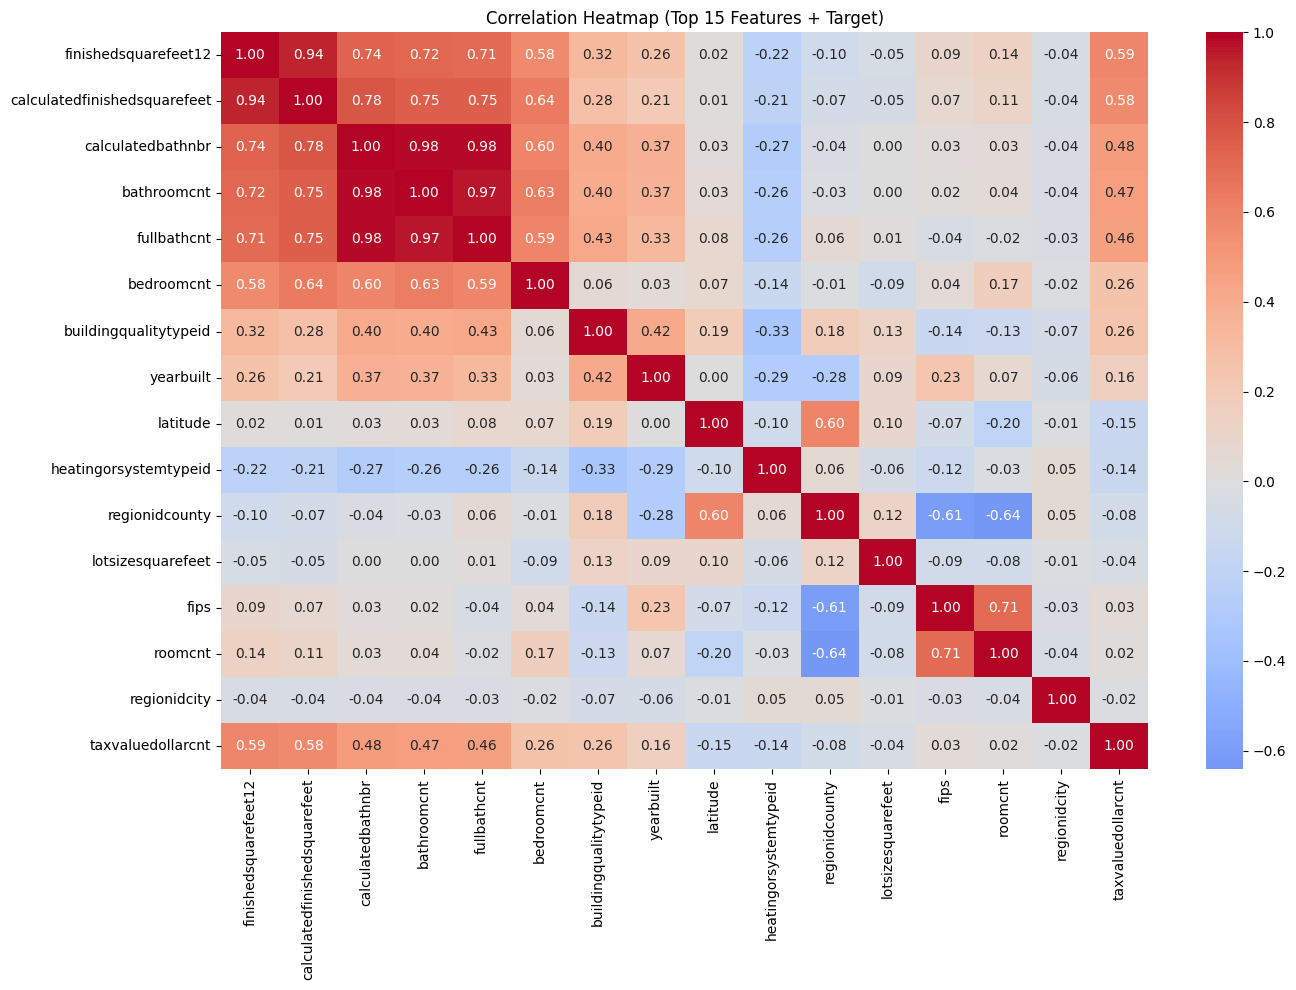

In [69]:
# Plot the correlation heatmap (top features only for readability)
top_features = target_corr.abs().sort_values(ascending=False).head(15).index.tolist()
top_features.append('taxvaluedollarcnt')

plt.figure(figsize=(14, 10))
sns.heatmap(df_encoded[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (Top 15 Features + Target)')
plt.tight_layout()
plt.show()

In [70]:
# Compute F-statistic for all features vs target
X_all = df_encoded.drop(columns=['taxvaluedollarcnt'])
y_all = df_encoded['taxvaluedollarcnt']

f_scores, p_values = f_regression(X_all, y_all)

# Create a dataframe with the results
f_score_df = pd.DataFrame({
    'Feature': X_all.columns,
    'F-Score': f_scores,
    'p-value': p_values
}).sort_values('F-Score', ascending=False)

print("F-Statistics for all features:")
display(f_score_df)

F-Statistics for all features:


,Feature,F-Score,p-value
5,finishedsquarefeet12,40191.181228,0.000000e+00
4,calculatedfinishedsquarefeet,37615.610919,0.000000e+00
3,calculatedbathnbr,23323.857262,0.000000e+00
0,bathroomcnt,21691.971892,0.000000e+00
7,fullbathcnt,20753.986738,0.000000e+00
1,bedroomcnt,5537.105042,0.000000e+00
2,buildingqualitytypeid,5344.167924,0.000000e+00
17,yearbuilt,1967.405115,0.000000e+00
9,latitude,1672.055268,0.000000e+00
8,heatingorsystemtypeid,1413.748145,1.440918e-306


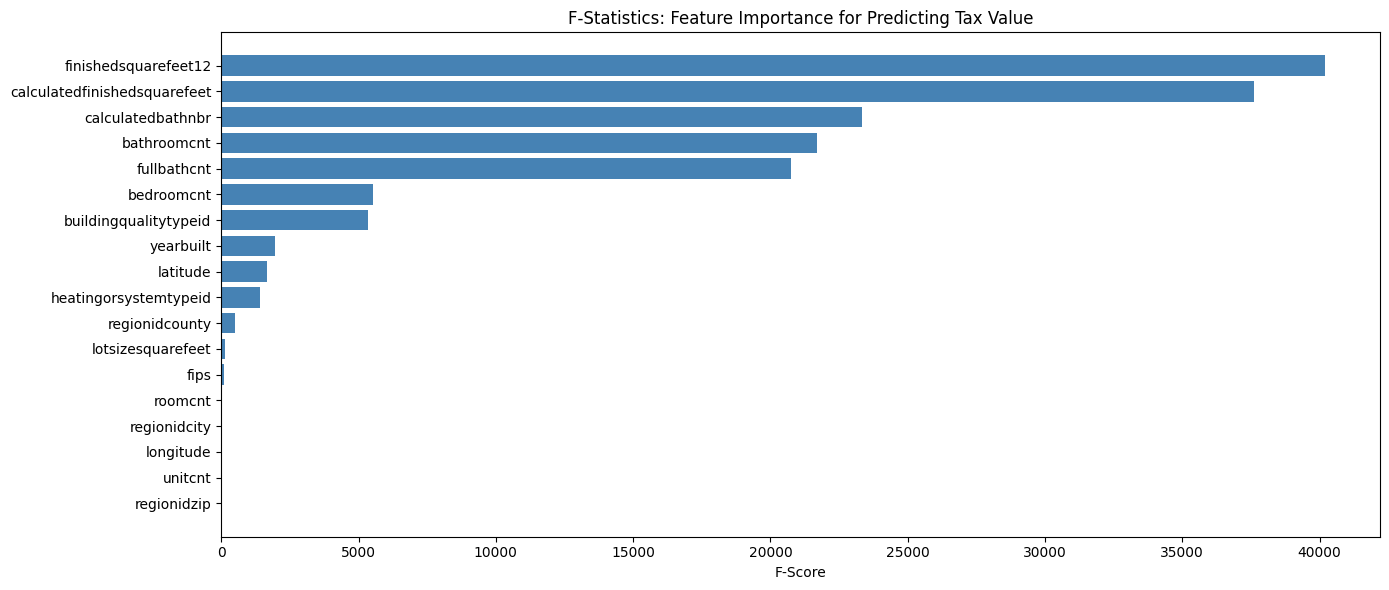

In [71]:
# Plot F-scores as a bar chart
plt.figure(figsize=(14, 6))
plt.barh(f_score_df['Feature'], f_score_df['F-Score'], color='steelblue')
plt.xlabel('F-Score')
plt.title('F-Statistics: Feature Importance for Predicting Tax Value')
plt.gca().invert_yaxis()  # highest score at top
plt.tight_layout()
plt.show()

In [72]:
# Forward Feature Selection (using LinearRegression)

X_fs = X_all.copy()
y_fs = y_all.copy()

model_lr = LinearRegression()

# Forward selection with max 10 features for speed
sfs_forward = SequentialFeatureSelector(
    model_lr,
    n_features_to_select=10,
    direction='forward',
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1
)

print("Feature Selection")
sfs_forward.fit(X_fs, y_fs)

forward_features = X_fs.columns[sfs_forward.get_support()].tolist()
print(f"\nForward Selection chose {len(forward_features)} features:")
print(forward_features)

Feature Selection

Forward Selection chose 10 features:
['bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'latitude', 'longitude', 'lotsizesquarefeet', 'roomcnt', 'yearbuilt']


In [73]:
# Backward Feature Selection
sfs_backward = SequentialFeatureSelector(
    model_lr,
    n_features_to_select=10,
    direction='backward',
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1
)

print("Backward Feature Selection.")
sfs_backward.fit(X_fs, y_fs)

backward_features = X_fs.columns[sfs_backward.get_support()].tolist()
print(f"\nBackward Selection chose {len(backward_features)} features:")
print(backward_features)

Backward Feature Selection.

Backward Selection chose 10 features:
['bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'fips', 'latitude', 'longitude', 'regionidcounty', 'roomcnt']


In [74]:
# Compare forward and backward selection results
common_features = set(forward_features) & set(backward_features)
print(f"Features selected by BOTH forward and backward: {common_features}")
print(f"Only in forward: {set(forward_features) - set(backward_features)}")
print(f"Only in backward: {set(backward_features) - set(forward_features)}")

Features selected by BOTH forward and backward: {'latitude', 'calculatedfinishedsquarefeet', 'bedroomcnt', 'bathroomcnt', 'longitude', 'finishedsquarefeet12', 'buildingqualitytypeid', 'roomcnt'}
Only in forward: {'yearbuilt', 'lotsizesquarefeet'}
Only in backward: {'regionidcounty', 'fips'}


#### **4.A Discussion:**  Describe in a paragraph what you see in the feature relationships and correlations.

Pay particular attention to especially interesting and/or strongly correlated feature relationships.
 How do the different methods for seeing relationships compare? Do they agree or disagree?



The correlation analysis shows that `finishedsquarefeet12` (0.588) and `calculatedfinishedsquarefeet` (0.575) have the strongest positive correlation with the target. These two features are also very highly correlated with each other, which makes sense because they both measure living area square footage. `calculatedbathnbr` (0.485) and `bathroomcnt` (0.471) are also strong predictors and very similar to each other.

The F-statistics confirm the same ranking: `finishedsquarefeet12` (F=40,191) and `calculatedfinishedsquarefeet` (F=37,616) are at the top, followed by bathroom-related features.

Forward and backward feature selection both selected 10 features and they agree on 8 of them: `bathroomcnt`, `bedroomcnt`, `buildingqualitytypeid`, `calculatedfinishedsquarefeet`, `finishedsquarefeet12`, `latitude`, `longitude`, and `roomcnt`. Forward also selected `yearbuilt` and `lotsizesquarefeet`, while backward selected `fips` and `regionidcounty`. This high agreement (80%) gives us confidence that these 8 shared features are truly important. Interestingly, both methods selected `latitude` and `longitude`, which means location is an important factor even though their simple correlations with the target are low.

### Part 4.B:  2-Dimensional Visualizations for Interesting Patterns  
   - Select three (3) pairs of features that exhibit meaningful relationships based on your previous analysis.
   - Create 2D scatter plots or density plots to explore interactions between these features.  
   - Provide brief interpretations of any observed patterns or trends.

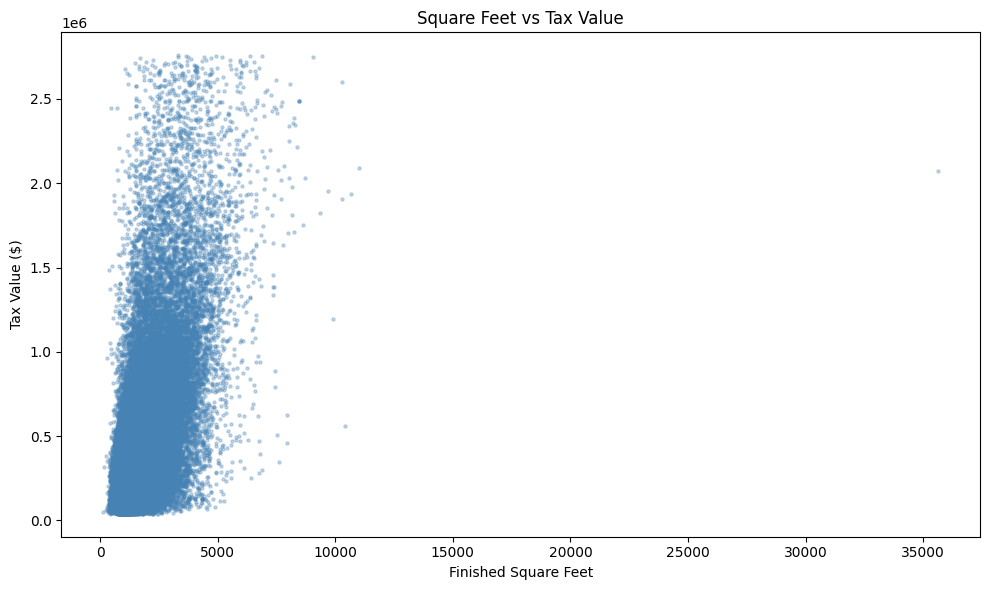

In [75]:
# Scatter plot 1: calculatedfinishedsquarefeet vs taxvaluedollarcnt
plt.figure(figsize=(10, 6))
plt.scatter(df_encoded['calculatedfinishedsquarefeet'],
            df_encoded['taxvaluedollarcnt'], alpha=0.3, s=5, color='steelblue')
plt.xlabel('Finished Square Feet')
plt.ylabel('Tax Value ($)')
plt.title('Square Feet vs Tax Value')
plt.tight_layout()
plt.show()

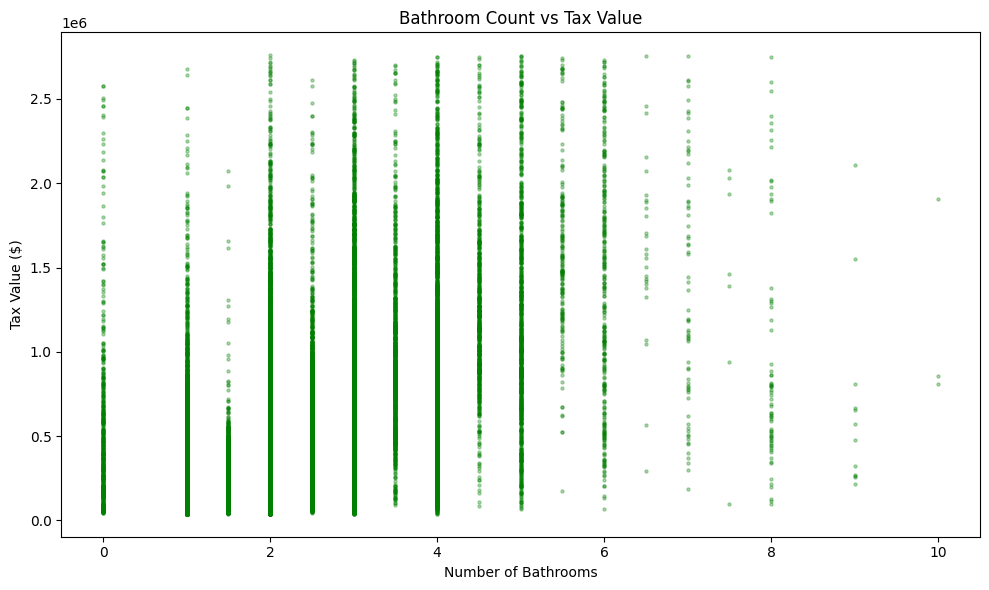

In [76]:
# Scatter plot 2: bathroomcnt vs taxvaluedollarcnt
plt.figure(figsize=(10, 6))
plt.scatter(df_encoded['bathroomcnt'],
            df_encoded['taxvaluedollarcnt'], alpha=0.3, s=5, color='green')
plt.xlabel('Number of Bathrooms')
plt.ylabel('Tax Value ($)')
plt.title('Bathroom Count vs Tax Value')
plt.tight_layout()
plt.show()

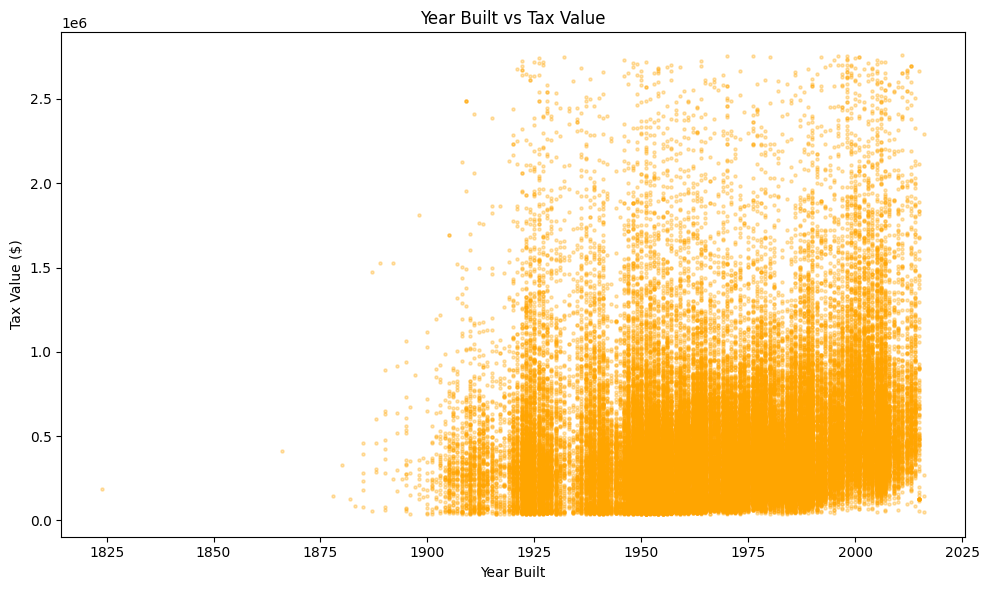

In [77]:
# Scatter plot 3: yearbuilt vs taxvaluedollarcnt
plt.figure(figsize=(10, 6))
plt.scatter(df_encoded['yearbuilt'],
            df_encoded['taxvaluedollarcnt'], alpha=0.3, s=5, color='orange')
plt.xlabel('Year Built')
plt.ylabel('Tax Value ($)')
plt.title('Year Built vs Tax Value')
plt.tight_layout()
plt.show()

#### **4.B Discussion:** Provide brief interpretations of any observed patterns or trends.


**Square Feet vs Tax Value:** There is a clear positive linear relationship. As the finished square footage increases, the tax value increases too. The relationship is strongest for properties under 4,000 sqft, and there is more variation for larger properties. This confirms that square footage is one of the best predictors (correlation = 0.575).

**Bathroom Count vs Tax Value:** More bathrooms generally means higher tax value. Properties with 1-2 bathrooms cluster around lower values ($200K-$500K), while properties with 3+ bathrooms tend to be more expensive. The pattern is step-like because bathroom count is a discrete number. There are some outliers with many bathrooms (up to 18) that might be errors.

**Year Built vs Tax Value:** Newer properties tend to have slightly higher tax values, but the relationship is weak (correlation = 0.159). There is a lot of spread at every year, which means year built alone is not a strong predictor. However, combined with other features (like in the feature selection results), it can still be useful.

## Part 5:  Feature Engineering: Investigate various transformations to better expose the underlying data patterns to machine learning algorithms. [6 pts]

**Important Notes:**  
- This last part is a bit open ended, since there is a huge variety of feature engineering techniques, most of which won't be useful for your particular dataset.
- Understand that you can't evaluate the final usefulness of these transformations
until you choose a model, and  models may respond differently to various transformations or obviate some transformations (e.g., ensemble methods already do feature selection).
- Therefore, write your transformations as functions or otherwise be prepared
to choose later on which transformations may be necessary.

**Investigate feature engineering, where appropriate:**

- Feature scaling: standardize or normalize features as necessary
- Decompose features (e.g., categorical into One-Hot feature sequence, date/time into two features data and time, etc.).
- Add promising transformations of features
    - Exponential $\exp(x_i)$ or logarithmic $\log(x_j)$
    - Polynomial features  ( $x_i^2$, $x_i - x_j$), products ($x_i*x_j$), or ratios ($x_i/x_j$)

**ToDo:**
- Pick at least three transformations to try.
- Try each one and evaluate its effect using correlations or F-scores or a feature selection algorithm.
- Answer the discussion question.

In [78]:
# Function to apply feature engineering transformations
def apply_transformations(df):
    df_fe = df.copy()
    return df_fe

df_fe = df_encoded.copy()

In [79]:
# Transformation 1: Log transform of target and square footage
# Log transforms help with right-skewed features

df_fe['log_sqft'] = np.log1p(df_fe['calculatedfinishedsquarefeet'])
df_fe['log_lotsizesquarefeet'] = np.log1p(df_fe['lotsizesquarefeet'])

# Check if log_sqft has better correlation with target
corr_original = df_fe['calculatedfinishedsquarefeet'].corr(df_fe['taxvaluedollarcnt'])
corr_log = df_fe['log_sqft'].corr(df_fe['taxvaluedollarcnt'])

print("Transformation 1: Log of Square Footage")
print(f"Original correlation with target: {corr_original:.4f}")
print(f"Log correlation with target:      {corr_log:.4f}")
print(f"Improvement: {abs(corr_log) - abs(corr_original):.4f}")

Transformation 1: Log of Square Footage
Original correlation with target: 0.5753
Log correlation with target:      0.5317
Improvement: -0.0437


In [80]:
# Transformation 2: Property age (current year - year built)
# Age might be more informative than raw year

df_fe['property_age'] = 2017 - df_fe['yearbuilt']  # dataset is from 2017

corr_year = df_fe['yearbuilt'].corr(df_fe['taxvaluedollarcnt'])
corr_age = df_fe['property_age'].corr(df_fe['taxvaluedollarcnt'])

print("Transformation 2: Property Age")
print(f"yearbuilt correlation with target:     {corr_year:.4f}")
print(f"property_age correlation with target:  {corr_age:.4f}")

Transformation 2: Property Age
yearbuilt correlation with target:     0.1588
property_age correlation with target:  -0.1588


In [81]:
# Transformation 3: Ratio - price per square foot proxy
# bed_bath_ratio and total rooms

# Total rooms = bedrooms + bathrooms
df_fe['total_rooms'] = df_fe['bedroomcnt'] + df_fe['bathroomcnt']

# Sqft per room
df_fe['sqft_per_room'] = df_fe['calculatedfinishedsquarefeet'] / df_fe['total_rooms'].replace(0, 1)

corr_rooms = df_fe['total_rooms'].corr(df_fe['taxvaluedollarcnt'])
corr_sqft_room = df_fe['sqft_per_room'].corr(df_fe['taxvaluedollarcnt'])

print("Transformation 3: Total Rooms and Sqft per Room")
print(f"total_rooms correlation with target:   {corr_rooms:.4f}")
print(f"sqft_per_room correlation with target: {corr_sqft_room:.4f}")

Transformation 3: Total Rooms and Sqft per Room
total_rooms correlation with target:   0.3950
sqft_per_room correlation with target: 0.1761


In [82]:
# Compare F-scores of new features vs originals
new_features = ['log_sqft', 'log_lotsizesquarefeet', 'property_age', 'total_rooms', 'sqft_per_room']

X_new = df_fe[new_features]
y_new = df_fe['taxvaluedollarcnt']

f_new, p_new = f_regression(X_new, y_new)

f_new_df = pd.DataFrame({
    'Feature': new_features,
    'F-Score': f_new,
    'p-value': p_new
}).sort_values('F-Score', ascending=False)

print("F-Statistics for new engineered features:")
display(f_new_df)

F-Statistics for new engineered features:


,Feature,F-Score,p-value
0,log_sqft,29957.562660,0.000000
3,total_rooms,14050.039279,0.000000
4,sqft_per_room,2433.295868,0.000000
2,property_age,1967.405115,0.000000
1,log_lotsizesquarefeet,7.269596,0.007015


#### **5 Discussion:** Describe in a paragraph why you chose these transformations and what you observed.


We tried three types of transformations. First, the log transformation of square footage actually made the correlation with the target worse (from 0.575 to 0.532). This tells us that the relationship between square footage and tax value is already close to linear, and the log transform does not help. The log of lot size was even worse (F-score of only 7.27). We will probably not use log transformations for these features.

Second, the property age feature (2017 - yearbuilt) just reversed the sign of the correlation (-0.159 vs 0.159). This is expected because age is the mirror image of year built. However, the F-score (1,967) confirms it still has some predictive value, and depending on the model, age might be more intuitive to interpret.

Third, the `total_rooms` feature (bedrooms + bathrooms) showed a stronger correlation (0.395) than bedrooms alone (0.261), with a strong F-score of 14,050. This is useful because it combines two related features into one. The `sqft_per_room` ratio also showed moderate predictive power (F-score = 2,433, correlation = 0.176), which could help the model understand the size of individual rooms. We will test these engineered features in Milestone 2 when we build models.

## **Appendix 1: Features of the Zillow Dataset**  

0. **parcelid**: Unique identifier for the property parcel.  
1. **airconditioningtypeid**: Identifier for the type of air conditioning installed.  
2. **architecturalstyletypeid**: Identifier for the architectural style of the property.  
3. **basementsqft**: Square footage of the basement.  
4. **bathroomcnt**: Number of bathrooms.  
5. **bedroomcnt**: Number of bedrooms.  
6. **buildingclasstypeid**: Identifier for the building framing type (e.g., wood frame, steel frame).  
7. **buildingqualitytypeid**: Numeric value indicating the quality of the building (higher values often indicate better quality).  
8. **calculatedbathnbr**: Calculated number of bathrooms, including fractional bathrooms.  
9. **decktypeid**: Identifier for the type of deck.  
10. **finishedfloor1squarefeet**: Square footage of the finished area on the first floor.  
11. **calculatedfinishedsquarefeet**: Total finished living area square footage.  
12. **finishedsquarefeet12**: Finished living area square footage.  
13. **finishedsquarefeet13**: Perimeter living area square footage.  
14. **finishedsquarefeet15**: Total area.  
15. **finishedsquarefeet50**: Square footage of the finished area on the upper floors.  
16. **finishedsquarefeet6**: Base unfinished and finished area square footage.  
17. **fips**: Federal Information Processing Standards code, uniquely identifying counties and county equivalents.  
18. **fireplacecnt**: Number of fireplaces.  
19. **fullbathcnt**: Number of full bathrooms.  
20. **garagecarcnt**: Number of cars that can fit in the garage.  
21. **garagetotalsqft**: Total square footage of the garage.  
22. **hashottuborspa**: Indicates if the property has a hot tub or spa.  
23. **heatingorsystemtypeid**: Identifier for the type of heating system.  
24. **latitude**: Latitude coordinate of the property.  
25. **longitude**: Longitude coordinate of the property.  
26. **lotsizesquarefeet**: Lot size in square feet.  
27. **poolcnt**: Number of pools on the property.  
28. **poolsizesum**: Total square footage of all pools.  
29. **pooltypeid10**: Identifier for spa or hot tub.  
30. **pooltypeid2**: Identifier for pool with spa or hot tub.  
31. **pooltypeid7**: Identifier for pool without hot tub or spa.  
32. **propertycountylandusecode**: County land use code for the property.  
33. **propertylandusetypeid**: Identifier for the property land use type.  
34. **propertyzoningdesc**: Description of the property's zoning.  
35. **rawcensustractandblock**: Unprocessed census tract and block identifier.  
36. **regionidcity**: Identifier for the city.  
37. **regionidcounty**: Identifier for the county.  
38. **regionidneighborhood**: Identifier for the neighborhood.  
39. **regionidzip**: Identifier for the ZIP code.  
40. **roomcnt**: Total number of rooms.  
41. **storytypeid**: Identifier for the type of stories in the building (e.g., basement, attic).  
42. **threequarterbathnbr**: Number of 3/4 bathrooms (typically includes a shower but no tub).  
43. **typeconstructiontypeid**: Identifier for the type of construction (e.g., frame, masonry).  
44. **unitcnt**: Number of units in the building (e.g., for multi-family properties).  
45. **yardbuildingsqft17**: Square footage of the 17th yard building (e.g., shed).  
46. **yardbuildingsqft26**: Square footage of the 26th yard building.  
47. **yearbuilt**: Year the property was built.  
48. **numberofstories**: Number of stories in the building.  
49. **fireplaceflag**: Indicates if the property has a fireplace.  
50. **assessmentyear**: Year the property was assessed.  
51. **taxdelinquencyflag**: Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.  
52. **taxdelinquencyyear**: The year in which the property’s taxes became delinquent.  
53. **censustractandblock**: A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy).  
54. **taxvaluedollarcnt**: Total assessed value of the property (land plus structure) in dollars.  


## Appendix 2: Summary of Basic Imputation Methods
Imputation depends on the data type and context. Below are common techniques for handling missing values.

---

### **1. Simple Imputation (Basic Methods)**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Drop Missing Values** | Few missing values (<5% of data) | `df.dropna()` | Quick and easy | Can remove valuable data |
| **Mean Imputation** | Normally distributed numerical data | `df.fillna(df.mean())` | Preserves mean; simple | Distorts variance, weak for skewed data |
| **Median Imputation** | Skewed numerical data | `df.fillna(df.median())` | Robust to outliers | May not capture patterns |
| **Mode Imputation** | Categorical features | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias |
| **Constant Value (e.g., 0)** | Special cases (e.g., unknown numerical data) | `df.fillna(0)` | Simple and interpretable | Can mislead model |
| **"Unknown" Category Imputation** (**New Addition**) | Categorical features with missing values | `df.fillna('Unknown')` | Keeps all rows, prevents data loss | May introduce artificial category |

---

### **2. Statistical & Advanced Imputation**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Interpolation** | Time series, ordered data | `df.interpolate(method='linear')` | Preserves trends | May not work for non-continuous data |
| **K-Nearest Neighbors (KNN)** | Small datasets, patterns in features | `KNNImputer(n_neighbors=5).fit_transform(df)` | Uses similar observations | Computationally expensive |
| **Multivariate Imputation (MICE)** | Complex relationships between variables | `IterativeImputer().fit_transform(df)` | Captures relationships | Slower than mean/median |
| **Regression Imputation** | When missing values depend on other variables | Train regression model to predict missing values | More accurate than mean/median | Risk of overfitting |

---

### **When to Use "Unknown" Category for Categorical Imputation**
✅ **Good for:**
- Categorical features where missing values may indicate meaningful differences.  
- Customer data (e.g., missing survey responses → "No Response").  
- Product categories where missing could be a separate group.  

❌ **Avoid if:**
- The missing category does **not** have a meaningful interpretation.
- The model might learn spurious patterns from an artificial category.

---

### **Which Method to Choose?**
| Scenario | Best Method |
|----------|------------|
| **Few missing values (<5%)** | Drop NaNs (`df.dropna()`) |
| **Numerical & normal distribution** | Mean (`df.fillna(df.mean())`) |
| **Numerical & skewed distribution** | Median (`df.fillna(df.median())`) |
| **Categorical features** | Mode (`df.fillna(df.mode().iloc[0])`) |
| **Categorical with possible meaning in missingness** | "Unknown" Category (`df.fillna('Unknown')`) |
| **Small dataset with patterns** | KNN Imputer (`KNNImputer()`) |
| **Complex relationships between features** | MICE / Iterative Imputer |

